# Libraries

In [30]:
import matplotlib
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from matplotlib.colors import ListedColormap
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score, mean_squared_error, mean_absolute_error, classification_report
pd.set_option('display.float_format', '{:.2f}'.format)

# XAI Dataset: Single decision tree

In [31]:
url = "https://raw.githubusercontent.com/isaakzyjiang/BAML-coursework/main/Decision%20Trees/datasets/df_xai.csv"

print("Starting data migration from GitHub...")

try:
    df_xai = pd.read_csv(url)
    print("Data loaded successfully")
except Exception as e:
    print(f"Error: {e}")

Starting data migration from GitHub...
Data loaded successfully


In [32]:
df_xai.head()

,x1,x2,y
0,-1.51,2.70,0.00
1,2.78,0.59,1.00
2,-4.13,-2.06,0.00
3,-5.30,2.20,1.00
4,1.21,1.25,1.00


Visualize the dataset

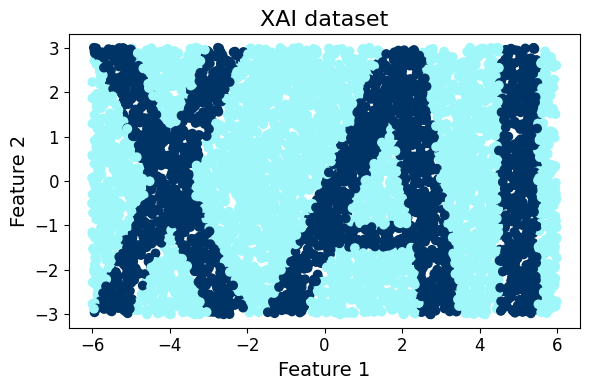

In [33]:
colors = ["#a0f7fa", "#003366"]
cm = matplotlib.colors.ListedColormap(colors)
plt.figure(figsize=(6, 4))
plt.scatter(df_xai["x1"], df_xai["x2"], c=df_xai["y"], cmap=cm)
plt.title("XAI dataset", fontsize=16)
plt.xlabel("Feature 1", fontsize=14)
plt.ylabel("Feature 2", fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()

Decision tree can easily separate two-dimensional XAI dataset.

In [34]:
X = df_xai[["x1", "x2"]].to_numpy()
y = df_xai["y"].to_numpy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=True, random_state=42)

tree = DecisionTreeClassifier()
tree.fit(X_train, y_train)

y_pred = tree.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.96      0.97      0.97       736
         1.0       0.96      0.94      0.95       464

    accuracy                           0.96      1200
   macro avg       0.96      0.96      0.96      1200
weighted avg       0.96      0.96      0.96      1200



Visualize decision boundary

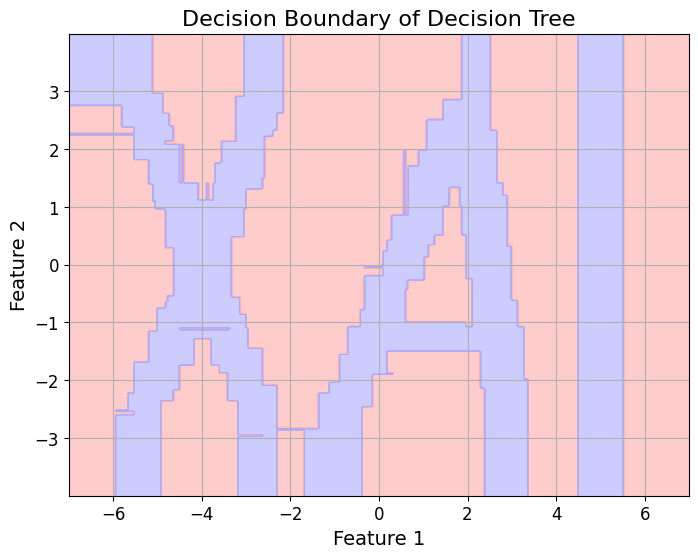

In [35]:
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

Z = tree.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

cm = ListedColormap(['#FFAAAA', '#AAAAFF'])

plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.6, cmap=cm)
plt.title("Decision Boundary of Decision Tree", fontsize=16)
plt.xlabel("Feature 1", fontsize=14)
plt.ylabel("Feature 2", fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(True)
plt.show()

Now plot the tree using the plot_tree function

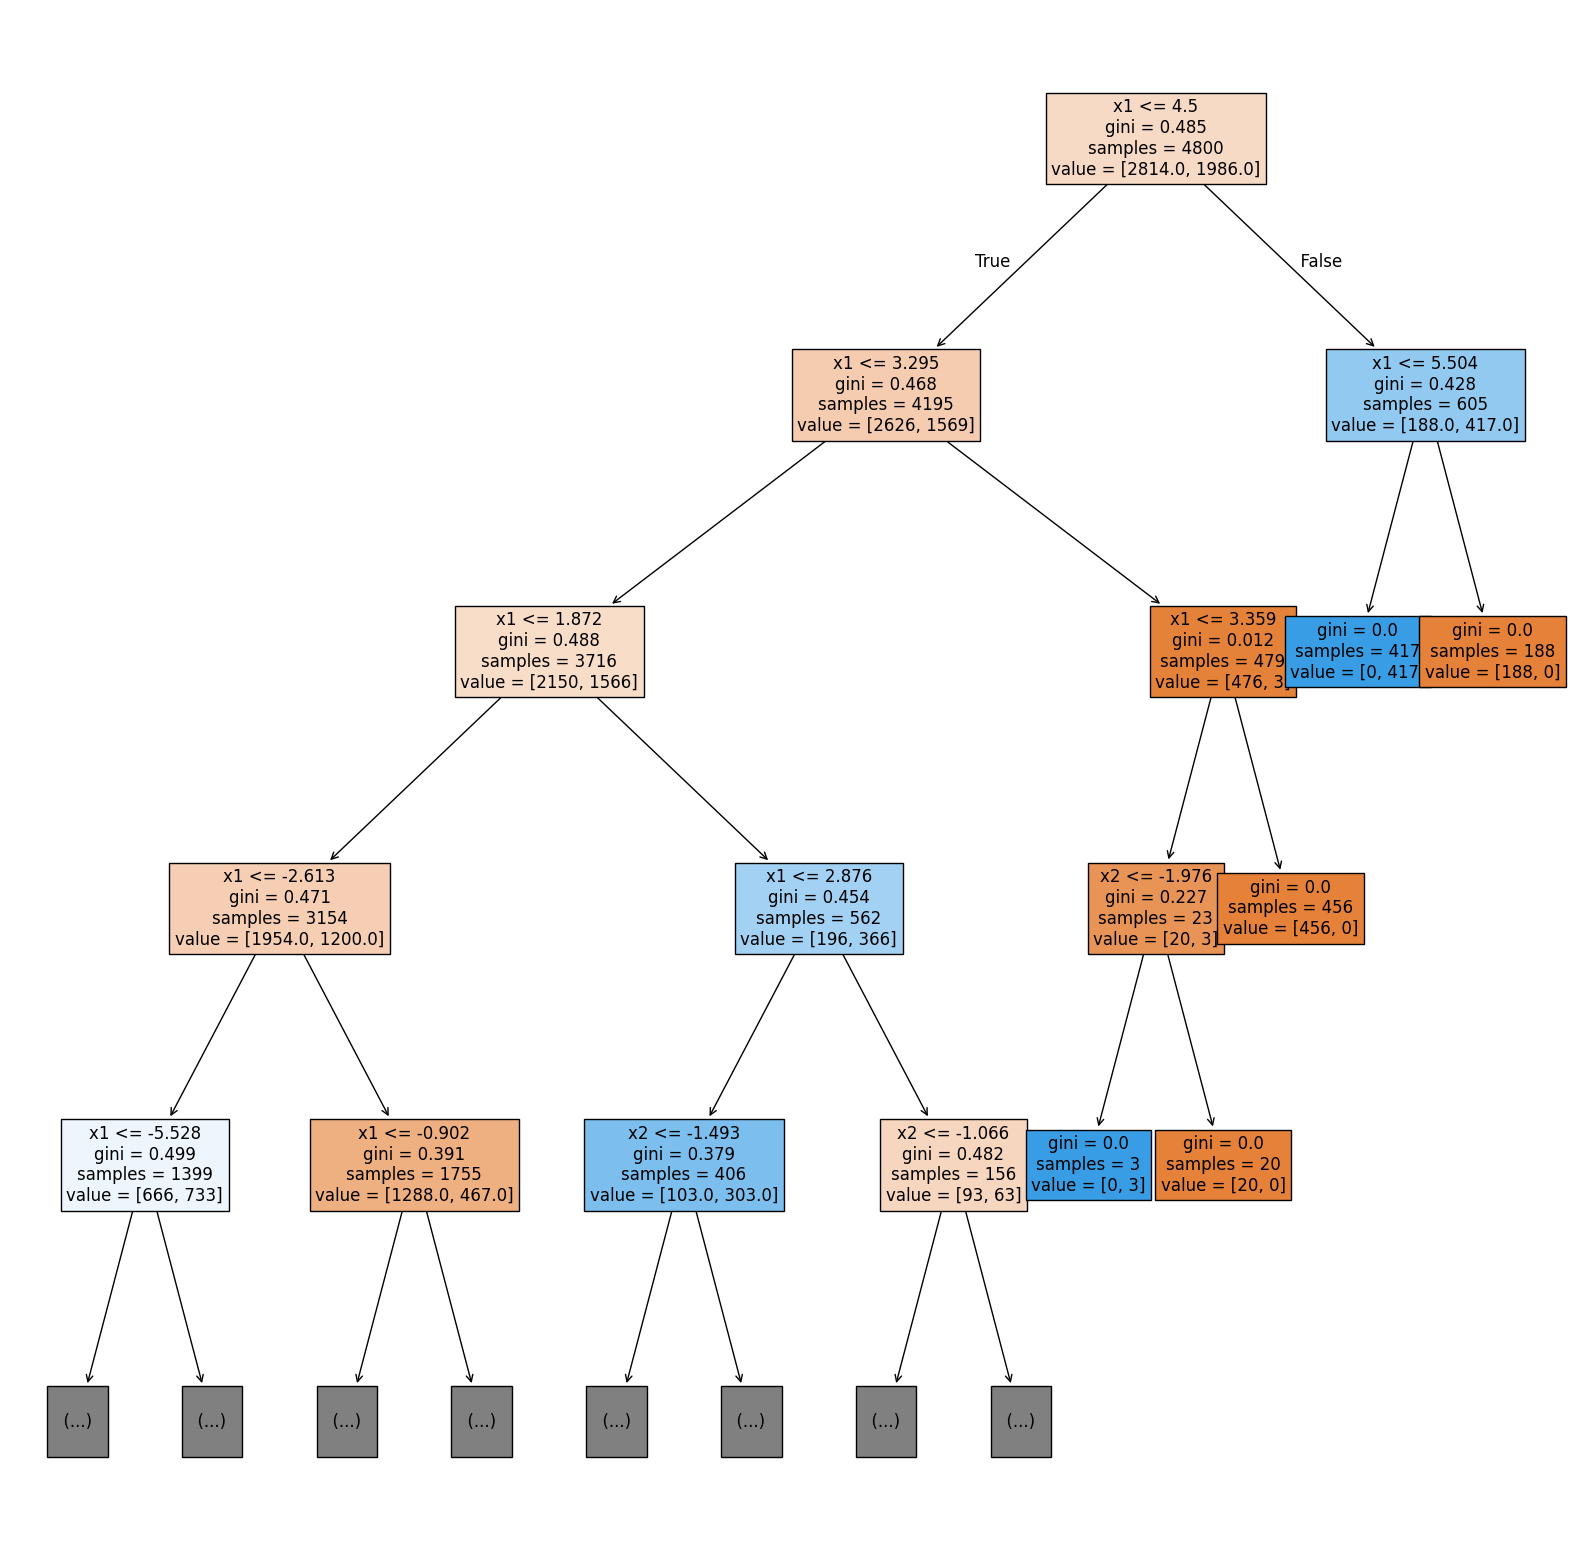

In [36]:
plt.figure(figsize=(20, 20))
plot_tree(tree, feature_names=["x1", "x2"], filled=True, impurity=True, max_depth=4, fontsize=12)
plt.show()

Grow the tree again but use cost complexity pruning with alpha=0.01.

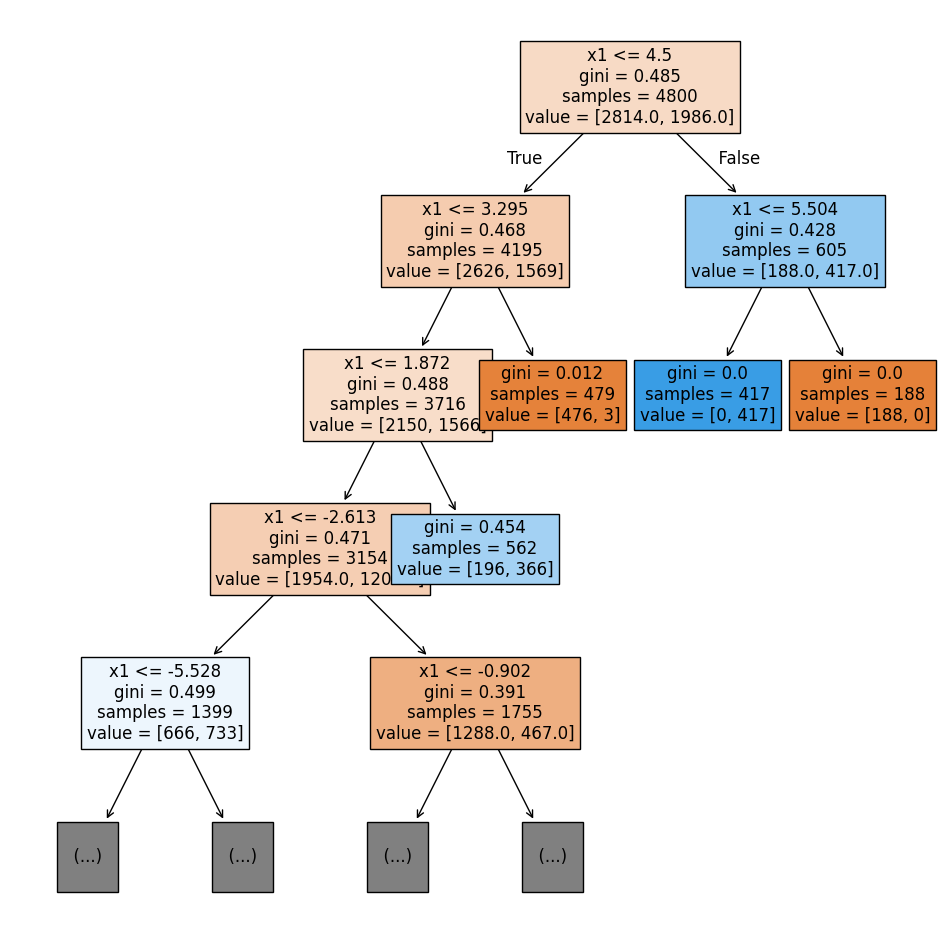

In [37]:
tree = DecisionTreeClassifier(ccp_alpha=0.01)
tree.fit(X_train, y_train)

plt.figure(figsize=(12, 12))
plot_tree(tree, feature_names=["x1", "x2"], filled=True, impurity=True, max_depth=4, fontsize=12)
plt.show()

# Decision Tree: Effects of pruning and max depth

In [38]:
from sklearn.datasets import make_regression
from sklearn.tree import DecisionTreeRegressor
from itertools import product

np.random.seed(42)
X, y = make_regression(n_samples=500, n_features=10, noise=10.0)

X_trainval, X_test, y_trainval, y_test = train_test_split(X, y, test_size=0.2, random_state=1)
X_train, X_val, y_train, y_val = train_test_split(X_trainval, y_trainval, test_size=0.25, random_state=1)

print(f"Train size: {X_train.shape[0]}, Validation: {X_val.shape[0]}, Test: {X_test.shape[0]}")

max_depths = [4, 5, 6, 7, 8, 9, None]
ccp_alphas = [0, 0.01, 0.05, 0.1, 0.2]

results = []

for depth, alpha in product(max_depths, ccp_alphas):
    model = DecisionTreeRegressor(max_depth=depth, ccp_alpha=alpha, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    mse = mean_squared_error(y_val, y_pred)
    results.append({
        "max_depth": "None" if depth is None else depth,
        "ccp_alpha": alpha,
        "mse": mse
    })

results_df = pd.DataFrame(results)

best_row = results_df.loc[results_df["mse"].idxmin()]
best_depth = None if best_row["max_depth"] == "None" else int(best_row["max_depth"])
best_alpha = best_row["ccp_alpha"]

print(f"\nBest hyperparameters from validation:")
print(f"  max_depth = {best_depth}")
print(f"  ccp_alpha = {best_alpha}")
print(f"  Validation MSE = {best_row['mse']:.4f}")

X_final_train = np.vstack([X_train, X_val])
y_final_train = np.concatenate([y_train, y_val])

final_model = DecisionTreeRegressor(max_depth=best_depth, ccp_alpha=best_alpha, random_state=42)
final_model.fit(X_final_train, y_final_train)
y_test_pred = final_model.predict(X_test)
test_mse = mean_squared_error(y_test, y_test_pred)

print(f"\nTest MSE with best model: {test_mse:.4f}")

Train size: 300, Validation: 100, Test: 100

Best hyperparameters from validation:
  max_depth = 6
  ccp_alpha = 0.0
  Validation MSE = 10354.7245

Test MSE with best model: 9974.6276


The following code visualizes the individual effects of max_depth and ccp_alpha while keeping the other one constant.

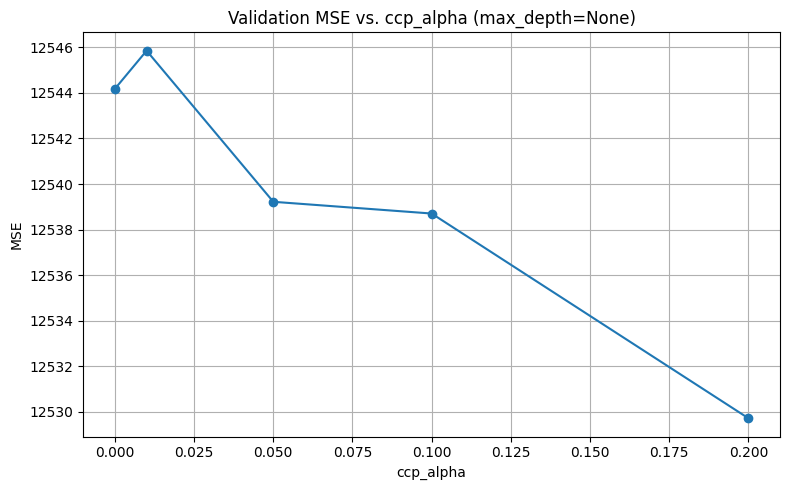

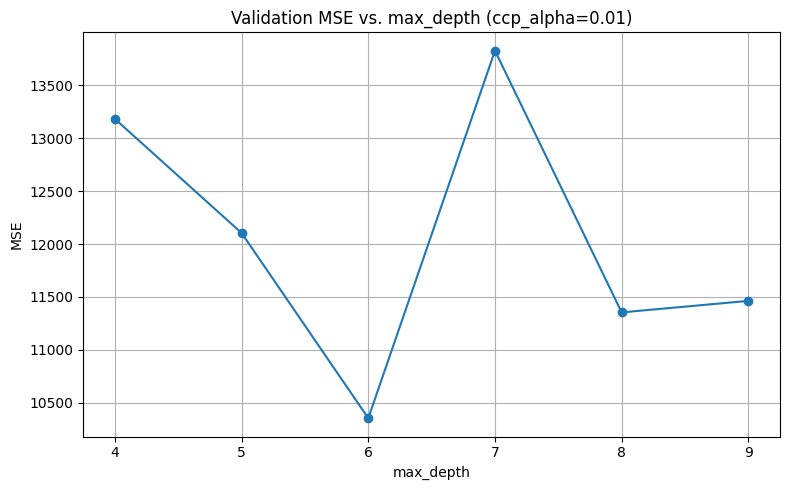

In [39]:
subset1 = results_df[results_df["max_depth"] == "None"].sort_values("ccp_alpha")

plt.figure(figsize=(8, 5))
plt.plot(subset1["ccp_alpha"], subset1["mse"], marker="o")
plt.title("Validation MSE vs. ccp_alpha (max_depth=None)")
plt.xlabel("ccp_alpha")
plt.ylabel("MSE")
plt.grid(True)
plt.tight_layout()
plt.show()

subset2 = results_df[results_df["ccp_alpha"] == 0.01].copy()
subset2 = subset2[subset2["max_depth"] != "None"]
subset2["max_depth"] = subset2["max_depth"].astype(int)
subset2 = subset2.sort_values("max_depth")

plt.figure(figsize=(8, 5))
plt.plot(subset2["max_depth"], subset2["mse"], marker="o")
plt.title("Validation MSE vs. max_depth (ccp_alpha=0.01)")
plt.xlabel("max_depth")
plt.ylabel("MSE")
plt.grid(True)
plt.tight_layout()
plt.show()

# Credit Card Fraud Dataset

In [40]:
url = "https://raw.githubusercontent.com/isaakzyjiang/BAML-coursework/main/Decision%20Trees/datasets/creditcard_processed.csv"

print("Starting data migration from GitHub...")

try:
    df_credit = pd.read_csv(url)
    print("Data loaded successfully")
except Exception as e:
    print(f"Error: {e}")

Starting data migration from GitHub...
Data loaded successfully


In [41]:
df_credit.head()

,isFraud,TransactionAmt,OperatingSystemVersion,BrowserVersion,ProductCode,CardNetwork,CardType,EmailDomainPayer,EmailDomainReceiver,OperatingSystemName,BrowserName
0,0,50.00,7.00,6.20,H,mastercard,credit,gmail.com,NaN,Android,samsung browser
1,0,15.00,11.10,11.00,H,visa,debit,anonymous.com,NaN,iOS,mobile safari
2,0,75.89,NaN,62.00,C,mastercard,credit,gmail.com,gmail.com,NaN,chrome
3,0,16.50,NaN,62.00,C,mastercard,debit,hotmail.com,hotmail.com,NaN,chrome
4,0,30.00,10.11,62.00,H,visa,debit,aol.com,NaN,Mac OS X,chrome


Print value counts of target variable "isFraud"

In [42]:
df_credit["isFraud"].value_counts()

isFraud
0    132915
1     11318
Name: count, dtype: int64

Print fraction of positive class

In [43]:
df_credit["isFraud"].mean()

np.float64(0.07847025299342036)

In [44]:
y_credit = df_credit["isFraud"]

cat_features = ["ProductCode", "CardNetwork", "CardType",
                "EmailDomainPayer", "EmailDomainReceiver",
                "OperatingSystemName", "BrowserName"]
features = ["TransactionAmt", "OperatingSystemVersion", "BrowserVersion"]
features.extend(cat_features)

X_credit = pd.get_dummies(df_credit[features], columns=cat_features, drop_first=True)
X_credit.shape

(144233, 187)

Train test splits

In [45]:
X_train, X_test, y_train, y_test = train_test_split(
    X_credit, y_credit, test_size=0.2, random_state=123445
)
print("Train imbalance:", np.mean(y_train))
print("Test imbalance:", np.mean(y_test))

Train imbalance: 0.07799906401123187
Test imbalance: 0.08035497625402988


In [46]:
X_train, X_test, y_train, y_test = train_test_split(
    X_credit, y_credit, test_size=0.2, stratify=y_credit, random_state=42
)
print("Train imbalance:", np.mean(y_train))
print("Test imbalance:", np.mean(y_test))

Train imbalance: 0.07846705839529926
Test imbalance: 0.07848303116441918


Code for cross validation, do not modify. Checkout the lecture notebook for usage examples.

In [47]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, recall_score,
    precision_score, f1_score, auc, precision_recall_curve
)
from sklearn.base import clone

def cross_validate_metrics(X, y, model, n_splits=5, random_state=42, sampling=None, predict_th=0.5):
    if isinstance(X, np.ndarray):
        X = pd.DataFrame(X)
    if isinstance(y, np.ndarray):
        y = pd.Series(y)

    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    accs, balanced_accs, recalls, precisions, f1s, auprcs = [], [], [], [], [], []

    for train_idx, val_idx in cv.split(X, y):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

        if sampling == "oversample":
            X_min = X_train[y_train == 1]
            X_maj = X_train[y_train == 0]

            X_min_os_delta = X_min.sample(n=len(X_maj) - len(X_min), replace=True, random_state=random_state)
            y_min_os_delta = pd.Series(1, index=X_min_os_delta.index)

            X_train = pd.concat([X_train, X_min_os_delta])
            y_train = pd.concat([y_train, y_min_os_delta])

        elif sampling == "undersample":
            X_min = X_train[y_train == 1]
            X_maj = X_train[y_train == 0]

            X_maj_us = X_maj.sample(n=len(X_min), random_state=random_state, replace=False)
            y_maj_us = pd.Series(0, index=X_maj_us.index)

            X_train = pd.concat([X_min, X_maj_us])
            y_train = pd.concat([pd.Series(1, index=X_min.index), y_maj_us])

        clf = clone(model)
        clf.fit(X_train, y_train)

        y_proba = clf.predict_proba(X_val)[:, 1]
        y_pred = (y_proba >= predict_th).astype(int)

        if hasattr(clf, "predict_proba"):
            y_proba = clf.predict_proba(X_val)[:, 1]
        elif hasattr(clf, "decision_function"):
            y_proba = clf.decision_function(X_val)
        else:
            y_proba = y_pred

        precision, recall, _ = precision_recall_curve(y_val, y_proba)

        accs.append(accuracy_score(y_val, y_pred))
        balanced_accs.append(balanced_accuracy_score(y_val, y_pred))
        recalls.append(recall_score(y_val, y_pred))
        precisions.append(precision_score(y_val, y_pred))
        f1s.append(f1_score(y_val, y_pred))
        auprcs.append(auc(recall, precision))

    return {
        "accuracy": np.mean(accs),
        "balanced_accuracy": np.mean(balanced_accs),
        "recall": np.mean(recalls),
        "precision": np.mean(precisions),
        "f1_score": np.mean(f1s),
        "auprc": np.nanmean(auprcs),
    }

Build a random forest and apply cross validation

In [48]:
m = RandomForestClassifier()

cross_validate_metrics(X_credit, y_credit, m)

{'accuracy': np.float64(0.9441944663782985),
 'balanced_accuracy': np.float64(0.7922964428057889),
 'recall': np.float64(0.6121217574469613),
 'precision': np.float64(0.6546540726074133),
 'f1_score': np.float64(0.6325313496640335),
 'auprc': np.float64(0.6385343159822364)}

Now use random forest but with Entropy

In [49]:
m = RandomForestClassifier(criterion="entropy")
cross_validate_metrics(X_credit, y_credit, m)

{'accuracy': np.float64(0.9441875342097361),
 'balanced_accuracy': np.float64(0.7914034749947975),
 'recall': np.float64(0.6101778261134333),
 'precision': np.float64(0.655184472370508),
 'f1_score': np.float64(0.6317661040572895),
 'auprc': np.float64(0.6375139477544063)}

Now apply balanced class weights.

In [50]:
m = RandomForestClassifier(class_weight="balanced")
cross_validate_metrics(X_credit, y_credit, m)

{'accuracy': np.float64(0.9352436795090278),
 'balanced_accuracy': np.float64(0.8174281317922716),
 'recall': np.float64(0.6776806250185423),
 'precision': np.float64(0.574180128555413),
 'f1_score': np.float64(0.6215989800160234),
 'auprc': np.float64(0.6240444539330731)}

In [51]:
m = RandomForestClassifier(class_weight="balanced_subsample")
cross_validate_metrics(X_credit, y_credit, m)

{'accuracy': np.float64(0.9349663514263694),
 'balanced_accuracy': np.float64(0.8177223212447062),
 'recall': np.float64(0.6786527077943066),
 'precision': np.float64(0.5723494892793959),
 'f1_score': np.float64(0.6209325347667141),
 'auprc': np.float64(0.6240044000941263)}

Oversampling of minority class

In [52]:
m = RandomForestClassifier()
cross_validate_metrics(X_credit, y_credit, m, sampling="oversample")

{'accuracy': np.float64(0.9287611058936915),
 'balanced_accuracy': np.float64(0.8228022427747561),
 'recall': np.float64(0.6971186111184847),
 'precision': np.float64(0.5354558519394774),
 'f1_score': np.float64(0.605653773170751),
 'auprc': np.float64(0.6619445386562787)}

Undersample majority class

In [53]:
m = RandomForestClassifier()
cross_validate_metrics(X_credit, y_credit, m, sampling="undersample")

{'accuracy': np.float64(0.7937503707545686),
 'balanced_accuracy': np.float64(0.8118293501985289),
 'recall': np.float64(0.8332738679853661),
 'precision': np.float64(0.25293990880029754),
 'f1_score': np.float64(0.3880561797468844),
 'auprc': np.float64(0.4532634830215903)}

Prediction threshold tuning

In [54]:
m = RandomForestClassifier()
cross_validate_metrics(X_credit, y_credit, m, predict_th=0.3)

{'accuracy': np.float64(0.9335380954088237),
 'balanced_accuracy': np.float64(0.8218779623161012),
 'recall': np.float64(0.6894317324793225),
 'precision': np.float64(0.5625436680684996),
 'f1_score': np.float64(0.61949787779483),
 'auprc': np.float64(0.6373387582099921)}

In [55]:
m = RandomForestClassifier()
cross_validate_metrics(X_credit, y_credit, m, predict_th=0.2)

{'accuracy': np.float64(0.9183681984294003),
 'balanced_accuracy': np.float64(0.8325617790784277),
 'recall': np.float64(0.7307820617117589),
 'precision': np.float64(0.4866950178921227),
 'f1_score': np.float64(0.5842353517998313),
 'auprc': np.float64(0.6381535728554726)}

Note that the area-under-the-precision-recall curve metric does not change (auprc).

# Melbourne Housing Dataset

In [56]:
url = "https://raw.githubusercontent.com/isaakzyjiang/BAML-coursework/main/Decision%20Trees/datasets/melbourne_clean.csv"

print("Starting data migration from GitHub...")

try:
    df_house = pd.read_csv(url)
    print("Data loaded successfully")
except Exception as e:
    print(f"Error: {e}")

Starting data migration from GitHub...
Data loaded successfully


In [57]:
df_house.head()

,Price,Suburb,Rooms,Type,Method,Date,Postcode,Bedrooms,Bathroom,Car,...,CouncilArea,Latitude,Longitude,Regionname,Propertycount,Rooms_winsorized,Landsize_winsorized,BuildingArea_winsorized,Car_Missing,distance_cbd_km
0,1480000.00,Abbotsford,2,House,S,3/12/2016,3067.00,2.00,1.00,1.00,...,Yarra City Council,-37.80,145.00,Northern Metropolitan,4019.00,2,202.00,NaN,False,4.25
1,1035000.00,Abbotsford,2,House,S,4/02/2016,3067.00,2.00,1.00,0.00,...,Yarra City Council,-37.81,144.99,Northern Metropolitan,4019.00,2,156.00,79.00,False,3.49
2,1465000.00,Abbotsford,3,House,SP,4/03/2017,3067.00,3.00,2.00,0.00,...,Yarra City Council,-37.81,144.99,Northern Metropolitan,4019.00,3,134.00,150.00,False,3.58
3,850000.00,Abbotsford,3,House,PI,4/03/2017,3067.00,3.00,2.00,1.00,...,Yarra City Council,-37.80,145.00,Northern Metropolitan,4019.00,3,94.00,NaN,False,4.20
4,941000.00,Abbotsford,2,House,S,7/05/2016,3067.00,2.00,1.00,0.00,...,Yarra City Council,-37.80,145.00,Northern Metropolitan,4019.00,2,181.00,NaN,False,3.77


Preprocessing

In [58]:
features = ["BuildingArea", "distance_cbd_km", "Bedrooms", "Bathroom", "Type", "Car_Missing", "Car", "Landsize"]
target = "Price"

df_house = df_house[df_house["Type"] != "unknown"]

df_house["BuildingArea"] = df_house["BuildingArea_winsorized"]
df_house["Landsize"] = df_house["Landsize_winsorized"]

df_clf = df_house.copy()
df_clf = df_clf[features + [target]].dropna()

X_house = pd.get_dummies(df_clf[features], drop_first=True)
y_house = df_clf["Price"]

Now let us build a most powerful model to predict Melbourne house prices. Run the following code with a random forest and a boosting model. Make sure to adjust the parameter grid, in particular for the boosting model.

In [59]:
from sklearn.model_selection import KFold, GridSearchCV, cross_val_score
from sklearn.ensemble import GradientBoostingRegressor

model = GradientBoostingRegressor()

param_grid = {
    "max_depth": [2, 3, 4, 5],
    "learning_rate": [0.1, 0.2, 0.5, 1]
}

inner_cv = KFold(n_splits=4, shuffle=True, random_state=123)

search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    scoring='neg_mean_squared_error',
    cv=inner_cv,
    n_jobs=-1
)

outer_cv = KFold(n_splits=5, shuffle=True, random_state=123)

nested_scores = cross_val_score(
    search, X_house, y_house,
    scoring='neg_mean_squared_error',
    cv=outer_cv,
    n_jobs=-1
)

print("Nested CV RMSEs:", np.sqrt(-nested_scores))
print("Mean RMSE:", np.sqrt(-nested_scores.mean()))

Nested CV RMSEs: [423458.60240337 403227.04575609 420490.26407891 450106.98704976
 421141.12427403]
Mean RMSE: 423952.2253531784
